In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [ ]:
#Initial Conditions
r_p = 6678                #km
r_a = 9940                #km
RAAN = np.pi / 4          #rads
i = 28 * np.pi / 180      #rads
argPeri = np.pi/6         #rads
theta = 40 * np.pi / 180 #rads
mu = 3.968e5              #km^3/s^2
r_Earth = 6378.137        #km
J2 = 1.08263e-3

#Derived quantities
a = (r_a + r_p)/2          #km
e = (r_a - r_p)/(r_a + r_p)
p = a*(1-e**2)             #km
r0_cart = p/(1+e*np.cos(theta)) #km
n = np.sqrt(mu/a**3)        #radians/s

#Time Quantities
t0 = 0                    #seconds
tf = 48 * 60 * 60         #seconds
t_span = (t0,tf)

In [ ]:
#Extract initial RTN vectors from orbital elements
r_peri = np.array([r0_cart*np.cos(theta),
                    r0_cart*np.sin(theta),
                    0])
v_peri = np.array([np.sqrt(mu/p)*np.sin(-theta),
                    np.sqrt(mu/p)*(e+np.cos(theta)),
                    0])

#Rotate them to ECI Frame, taken from Acosta_pset1.py
cR, sR = np.cos(RAAN), np.sin(RAAN)
cA, sA = np.cos(argPeri), np.sin(argPeri)
cI, sI = np.cos(i), np.sin(i)

ECI_mat = np.array([
    [cR*cA - sR*sA*cI, -cR*sA - sR*cA*cI,  sR*sI],
    [sR*cA + cR*sA*cI, -sR*sA + cR*cA*cI, -cR*sI],
    [sA*sI,             cA*sI,             cI]
])

r_ECI = np.matmul(ECI_mat, r_peri.T)
v_ECI = np.matmul(ECI_mat, v_peri)

#RTN Basis Vectors
h_vec = np.cross(r_ECI, v_ECI)
h = np.sqrt(mu*p)

i_R = r_ECI / np.linalg.norm(r_ECI)
i_N = h_vec / np.linalg.norm(h_vec)
i_T = np.cross(i_N, i_R)

#Change to RTN Basis
RTN_mat = np.array([i_R, i_T, i_N])
r0 = np.matmul(RTN_mat, r_ECI)
v0 = np.matmul(RTN_mat, v_ECI)

state_0 = (RAAN, argPeri, e, i, theta, a)
# print(np.isclose(np.linalg.norm(r0), p/(1+e*np.cos(theta)))) #sanity check

True


In [ ]:
def J2_perturb(r, i, u):
  const = -3*J2*mu*r_Earth**2 / (2*r**4)
  R = const * (1-3 * np.sin(i)**2 * np.sin(u)**2)
  T = const * (np.sin(i)**2 * np.sin(2*u))
  N = const * (np.sin(2*i) * np.sin(u))
  return R, T, N

def ode_sys(t, state):
  RAAN, argPeri, e, i, theta, a = state

  p = a * (1-e**2)
  h = np.sqrt(mu * p)
  r = p / (1+e*np.cos(theta))
  u = argPeri + theta
  R, T, N = J2_perturb(r, i, u)

  da = (2 * a**2 / h) * (e * np.sin(theta) * R + (p / r) * T)
  dRAAN = (r * np.sin(u) / (h * np.sin(i))) * N
  dargPeri = (-1 / (h * e) * np.cos(theta) * p * R +
                1 / (h * e) * (p + r) * np.sin(theta) * T -
                (r * np.sin(u) * np.cos(i) / (h * np.sin(i))) * N)
  dh = r*T
  de = (1 / h) * (p * np.sin(theta) * R + ((p + r) * np.cos(theta) + r * e) * T)
  di = (r * np.cos(u) / h) * N
  dtheta = h / r**2 + (1 / (h * e)) * (p * np.cos(theta) * R - (p + r) * np.sin(theta) * T)

  return (dRAAN, dargPeri, de, di, dtheta, da)

def get_h(states):
  RAAN, argPeri, e, i, theta, a = states
  return np.sqrt(mu * a *(1-e**2))

def plot(x,y,title,x_label,y_label):
  fig, ax = plt.subplots()
  ax.plot(x, y)

  ax.set_title(title)
  ax.set_xlabel(x_label)
  ax.set_ylabel(y_label)

  return fig, ax

def RAAN_drift(t):
  c = -3/2 * n *J2 * (r_Earth/p)**2 * np.cos(i)
  return c * t + RAAN

def argPeri_drift(t):
  c = 3/2 * J2 * (r_Earth/p)**2 * n * (2-2.5*np.sin(i)**2)
  return c * t + argPeri


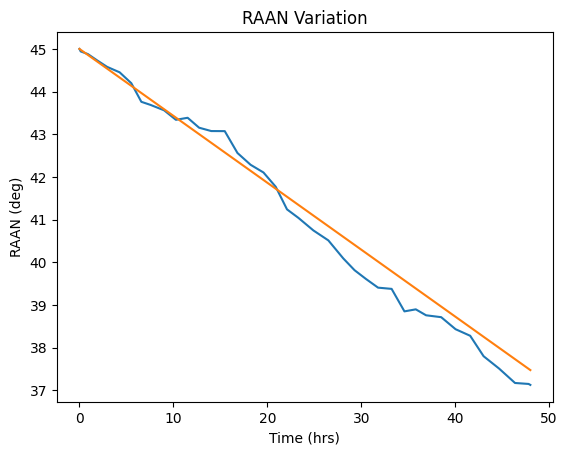

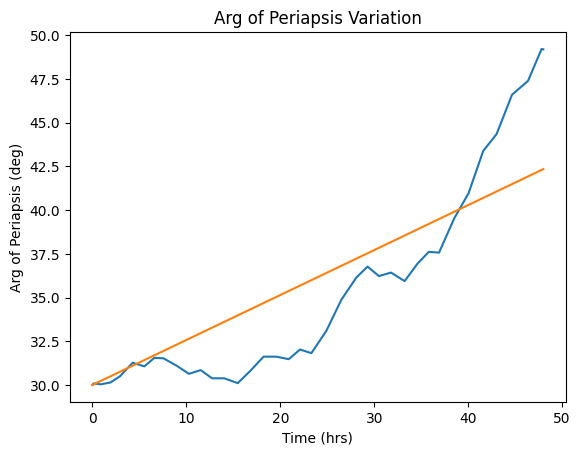

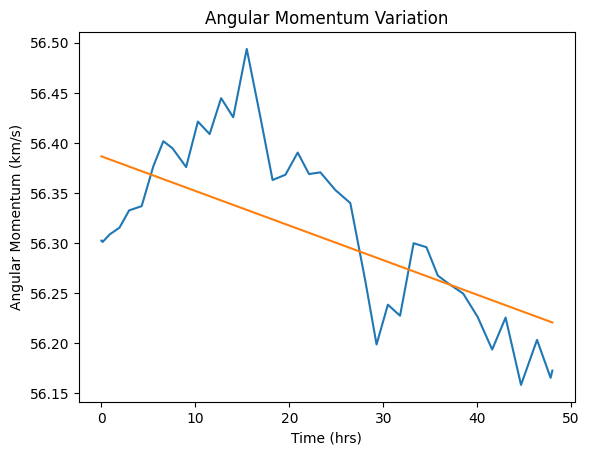

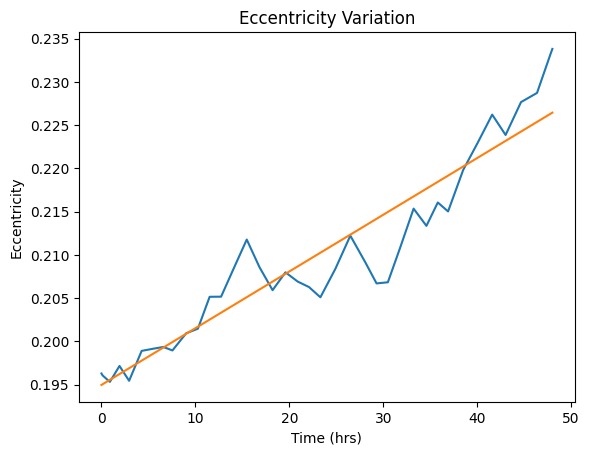

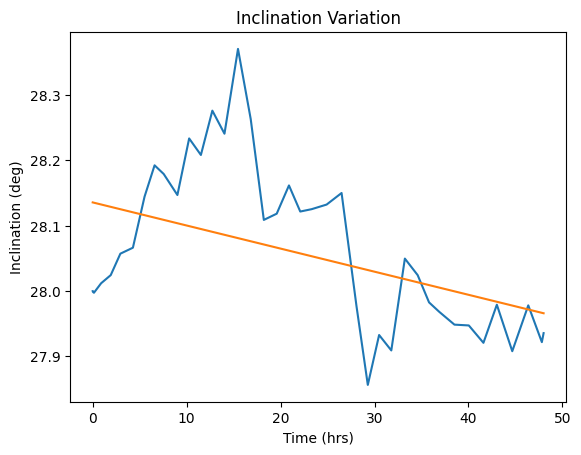

In [ ]:
oe = solve_ivp(ode_sys, t_span, state_0)
hrs = oe.t/3600

mean_RAAN_drift = RAAN_drift(oe.t)
RAAN_fig, RAAN_ax = plot(hrs, np.degrees(oe.y[0]),
               "RAAN Variation", "Time (hrs)", "RAAN (deg)")
RAAN_ax.plot(hrs, np.degrees(mean_RAAN_drift))

mean_aPeri_drift = argPeri_drift(oe.t)
aPeri_fig, aPeri_ax = plot(hrs, np.degrees(oe.y[1]),
               "Arg of Periapsis Variation", "Time (hrs)", "Arg of Periapsis (deg)")
aPeri_ax.plot(hrs, np.degrees(mean_aPeri_drift))

h_drift = get_h(oe.y) * 1e-3
slope, intercept = np.polyfit(hrs, h_drift, 1)
aPeri_fig, aPeri_ax = plot(hrs, h_drift,
                        "Angular Momentum Variation", "Time (hrs)",
                        "Angular Momentum (km/s)")
h_drift = lambda t:t*slope + intercept
aPeri_ax.plot(hrs, h_drift(hrs))

e_vals = oe.y[2]
slope, intercept = np.polyfit(hrs, e_vals, 1)
aPeri_fig, aPeri_ax = plot(hrs, e_vals,
                        "Eccentricity Variation", "Time (hrs)",
                        "Eccentricity")
e_drift = lambda t:t*slope + intercept
aPeri_ax.plot(hrs, h_drift(hrs))

i_vals = oe.y[3]
slope, intercept = np.polyfit(hrs, i_vals, 1)
aPeri_fig, aPeri_ax = plot(hrs, np.degrees(i_vals),
                        "Inclination Variation", "Time (hrs)",
                        "Inclination (deg)")
e_drift = lambda t:t*slope + intercept
aPeri_ax.plot(hrs, np.degrees(e_drift(hrs)))